## Machine Learning 1
### Ingeniería Electrónica 

**Clase 4: Práctica Integrada de Preprocesamiento de Datos, Análisis Exploratorio (EDA Profundo) y Modelado Baseline**

---

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual de gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("tab10")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("=== ENTORNO DE TRABAJO CONFIGURADO CORRECTAMENTE ===")


=== ENTORNO DE TRABAJO CONFIGURADO CORRECTAMENTE ===


## 1. Fuentes de Datos, Carga y Unificación Automatizada (Reglamento Nuevo)

En la gestión de datos académicos del **Reglamento Nuevo**, las planillas de calificaciones suelen encontrarse disgregadas por año lectivo y ciclo académico (`rendimiento_año_2024_ciclo_2_anon.xlsx`, `rendimiento_año_2025_ciclo_1_anon.xlsx`, etc.). Para realizar analítica avanzada y entrenar modelos de aprendizaje automático, el primer paso es consolidar programáticamente estas fuentes en una base de datos unificada en formato CSV.

### Fundamentación Matemática de la Ausencia de Datos

Definimos la matriz de datos completa $Y = (Y_{obs}, Y_{mis})$, donde $Y_{obs}$ representa las observaciones presentes y $Y_{mis}$ los valores faltantes. La matriz indicadora de ausencia $M_{ij} \in \{0, 1\}$ denota si la característica $j$ para la instancia $i$ está ausente.

1. **Missing Completely at Random (MCAR)**: La probabilidad de ausencia es independiente de cualquier variable:
   $$P(M \mid Y_{obs}, Y_{mis}) = P(M)$$
2. **Missing at Random (MAR)**: La probabilidad de ausencia depende exclusivamente de las variables observadas:
   $$P(M \mid Y_{obs}, Y_{mis}) = P(M \mid Y_{obs})$$
3. **Missing Not at Random (MNAR)**: La probabilidad de ausencia depende directamente de los valores no observados:
   $$P(M \mid Y_{obs}, Y_{mis}) \neq P(M \mid Y_{obs})$$


In [2]:
def unify_excel_datasets(input_dir: str, output_csv_path: str) -> pd.DataFrame:
    """
    Lee programáticamente todos los archivos .xlsx de la carpeta dada, los unifica
    en un único DataFrame y los exporta como archivo .csv.
    """
    excel_files = sorted(glob.glob(os.path.join(input_dir, "*.xlsx")))
    print(f"Archivos .xlsx detectados en '{input_dir}': {len(excel_files)}")
    
    dfs = []
    for filepath in excel_files:
        filename = os.path.basename(filepath)
        df_part = pd.read_excel(filepath)
        print(f" -> Cargando {filename}: {df_part.shape[0]} filas, {df_part.shape[1]} columnas.")
        dfs.append(df_part)
        
    unified_df = pd.concat(dfs, ignore_index=True)
    unified_df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
    print(f"\n-> Dataset unificado guardado exitosamente en: '{output_csv_path}'")
    print(f"   Dimensiones finales: {unified_df.shape[0]} filas x {unified_df.shape[1]} columnas.")
    return unified_df

# Ruta de origen y destino
csv_path = "reglamento_nuevo_unificado.csv"
excel_folder = "reglamentonuevo"

if not os.path.exists(csv_path) and os.path.exists(excel_folder):
    df_raw = unify_excel_datasets(excel_folder, csv_path)
else:
    df_raw = pd.read_csv(csv_path)
    print(f"-> Dataset cargado directamente desde '{csv_path}' ({df_raw.shape[0]} filas, {df_raw.shape[1]} columnas)")

# Creación de la variable objetivo de RiesgoAcadémico (1 = No Aprobado / Riesgo, 0 = Aprobado)
df_raw['condicion_riesgo'] = (df_raw['Aprobado'] == 'N').astype(int)

# Extracción de la especialidad/carrera corta (e.g. ELE, CIV, MCT, IND, CGF, MEC, ECA)
df_raw['Carrera_Corta'] = df_raw['Cod.Car.Sec'].astype(str).str.split('-').str[0]

# Clasificación de materias entre Cursos Básicos y Ciclo Profesional
basic_keywords = ['CALCULO', 'FISICA', 'GEOMETRIA', 'ALGEBRA', 'QUIMICA', 'DIBUJO', 'PROBABILIDAD', 'ESTATICA', 'MECANICA Y CALOR', 'ELECTRICIDAD Y MAGNETISMO', 'METODOS NUMERICOS', 'PROGRAMACION']
def get_cycle_type(asig):
    asig_str = str(asig).upper()
    return 'Cursos Básicos' if any(kw in asig_str for kw in basic_keywords) else 'Ciclo Profesional'

df_raw['Tipo_Ciclo'] = df_raw['Asignatura'].apply(get_cycle_type)

# Score de Rendimiento Académico Promedio de Parciales
df_raw['Score_Rendimiento'] = (df_raw['Primer.Par'] + df_raw['Segundo.Par']) / 2.0

# Simulación de nulos en calificaciones de exámenes parciales no rendidos para imputación
df_raw['Primer_Parcial'] = df_raw['Primer.Par'].replace(0, np.nan)
df_raw['Segundo_Parcial'] = df_raw['Segundo.Par'].replace(0, np.nan)


-> Dataset cargado directamente desde 'reglamento_nuevo_unificado.csv' (64295 filas, 29 columnas)


In [3]:
def inspect_data_quality_extended(df: pd.DataFrame):
    """
    Auditoría profunda de la calidad de datos: verifica explícitamente NaNs, nulos,
    valores vacíos/inválidos, ceros y momentos estadísticos (Media, Mediana, Std, Skewness, Kurtosis).
    """
    total_rows = len(df)
    records = []
    
    for col in df.columns:
        series = df[col]
        # Conteo de NaNs / Nulos
        nan_count = series.isna().sum()
        nan_pct = (nan_count / total_rows) * 100
        
        # Conteo de Ceros
        zero_count = (series == 0).sum() if pd.api.types.is_numeric_dtype(series) else 0
        zero_pct = (zero_count / total_rows) * 100
        
        # Conteo de cadenas vacías o representaciones no válidas
        empty_str_count = series.astype(str).str.strip().isin(['', 'NaN', 'nan', 'null', 'N/A', 'None']).sum() if series.dtype == 'object' else 0
        
        # Momentos estadísticos
        if pd.api.types.is_numeric_dtype(series):
            clean_s = series.dropna()
            mean_val = clean_s.mean()
            median_val = clean_s.median()
            std_val = clean_s.std()
            q1 = clean_s.quantile(0.25)
            q3 = clean_s.quantile(0.75)
            iqr_val = q3 - q1
            skew_val = clean_s.skew()
            kurt_val = clean_s.kurtosis()
        else:
            mean_val = median_val = std_val = iqr_val = skew_val = kurt_val = np.nan
            
        records.append({
            'Columna': col,
            'Tipo Dato': series.dtype,
            'Nulos/NaNs': nan_count,
            '% NaNs': round(nan_pct, 2),
            'Ceros (0)': zero_count,
            '% Ceros': round(zero_pct, 2),
            'Media': round(mean_val, 2) if not np.isnan(mean_val) else '-',
            'Mediana': round(median_val, 2) if not np.isnan(median_val) else '-',
            'Std': round(std_val, 2) if not np.isnan(std_val) else '-',
            'IQR': round(iqr_val, 2) if not np.isnan(iqr_val) else '-',
            'Asimetría (Skew)': round(skew_val, 2) if not np.isnan(skew_val) else '-',
            'Curtosis': round(kurt_val, 2) if not np.isnan(kurt_val) else '-'
        })
        
    audit_df = pd.DataFrame(records)
    print("=== DIAGNÓSTICO PROFUNDO DE CALIDAD DE DATOS Y MOMENTOS ESTADÍSTICOS ===")
    print(f"Total Registros: {total_rows} | Total Columnas: {len(df.columns)}")
    print(f"Uso Estimado de Memoria: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB\n")
    display(audit_df)
    return audit_df

audit_report = inspect_data_quality_extended(df_raw)


=== DIAGNÓSTICO PROFUNDO DE CALIDAD DE DATOS Y MOMENTOS ESTADÍSTICOS ===
Total Registros: 64295 | Total Columnas: 35


Uso Estimado de Memoria: 39.19 MB



,Columna,Tipo Dato,Nulos/NaNs,% NaNs,Ceros (0),% Ceros,Media,Mediana,Std,IQR,Asimetría (Skew),Curtosis
0,ALUMNO_ID,str,0,0.00,0,0.00,-,-,-,-,-,-
1,Cod.Asign,int64,0,0.00,0,0.00,16747.53,13734.0,6068.58,9893.0,-0.46,-0.46
2,Asignatura,str,0,0.00,0,0.00,-,-,-,-,-,-
3,Cod.Car.Sec,str,0,0.00,0,0.00,-,-,-,-,-,-
4,Cod.Curso,int64,0,0.00,0,0.00,5.66,5.0,3.48,5.0,0.48,-0.69
5,Convocatoria,int64,0,0.00,0,0.00,1.31,1.0,0.46,1.0,0.81,-1.34
6,Anho,int64,0,0.00,0,0.00,2024.62,2025.0,0.49,1.0,-0.49,-1.76
7,Semestre,int64,0,0.00,0,0.00,1.7,2.0,0.46,1.0,-0.86,-1.25
8,Doc.Firma,int64,0,0.00,17019,26.47,27895.33,37503.0,16747.18,38263.0,-1.06,-0.86
9,Aprobado,str,0,0.00,0,0.00,-,-,-,-,-,-


## 2. Análisis Exploratorio de Datos (EDA Profundo y Multidimensional)

En esta sección profundizamos el análisis estadístico incorporando gráficos específicos de retención académica por ciclo de estudio y comparativas de rendimiento por semestre y carrera, **previo a la matriz de correlación**.

### Formulaciones Matemáticas Descriptivas Avanzadas
- **Media Aritmética ($\mu$)**: $\mu = \frac{1}{N}\sum_{i=1}^N x_i$
- **Asimetría de Fisher-Pearson ($g_1$)**:
  $$g_1 = \frac{\frac{1}{N} \sum_{i=1}^N (x_i - \bar{x})^3}{\left[\frac{1}{N} \sum_{i=1}^N (x_i - \bar{x})^2\right]^{3/2}}$$
- **Curtosis de Excess ($g_2$)**:
  $$g_2 = \frac{\frac{1}{N} \sum_{i=1}^N (x_i - \bar{x})^4}{\left[\frac{1}{N} \sum_{i=1}^N (x_i - \bar{x})^2\right]^2} - 3$$
- **Tasa de Retención / Reprobación ($R_m$)**:
  $$R_m = \frac{\sum_{i=1}^{N_m} \mathbb{I}(\text{Estado}_i = \text{'No Aprobado'})}{N_m} \times 100\%$$


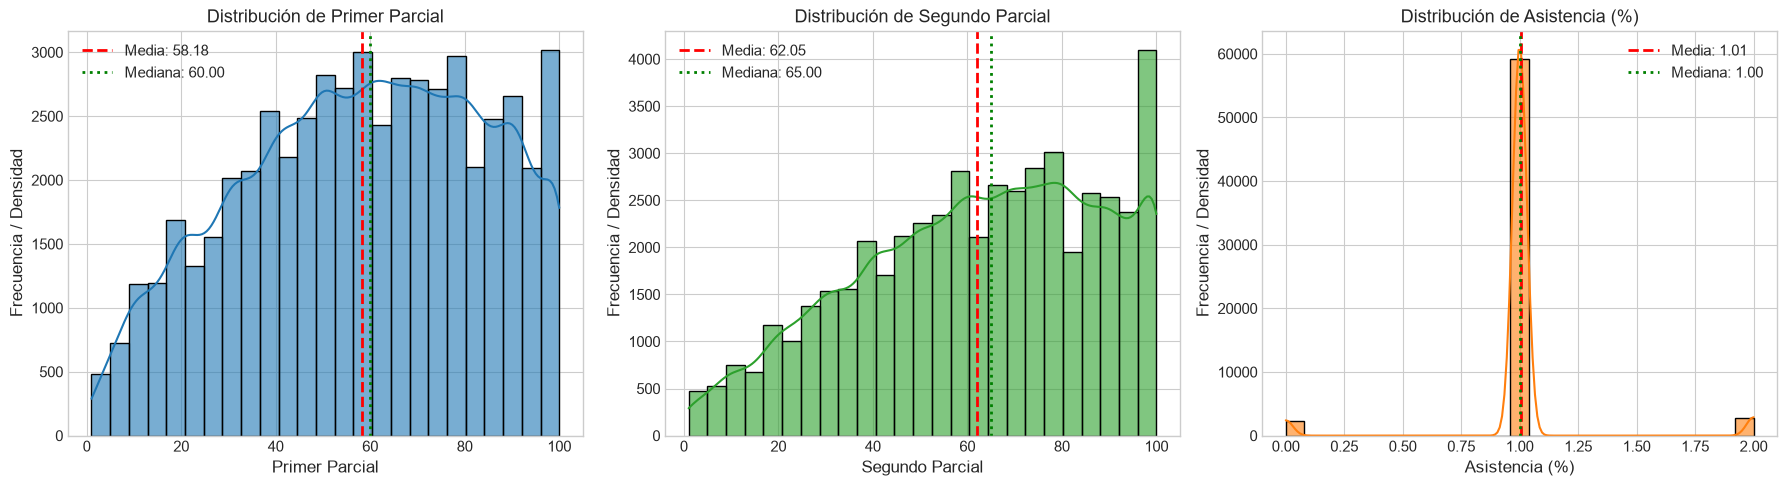

In [4]:
def plot_eda_distributions_and_kde(df: pd.DataFrame):
    """
    Genera histogramas y gráficas KDE para las variables de rendimiento numérico.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    num_cols = ['Primer_Parcial', 'Segundo_Parcial', 'Asis']
    titles = ['Primer Parcial', 'Segundo Parcial', 'Asistencia (%)']
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
    
    for ax, col, title, color in zip(axes, num_cols, titles, colors):
        if col in df.columns:
            data = df[col].dropna()
            sns.histplot(data, kde=True, ax=ax, color=color, bins=25, edgecolor='black', alpha=0.6)
            ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data.mean():.2f}')
            ax.axvline(data.median(), color='green', linestyle=':', linewidth=2, label=f'Mediana: {data.median():.2f}')
            ax.set_title(f'Distribución de {title}')
            ax.set_xlabel(title)
            ax.set_ylabel('Frecuencia / Densidad')
            ax.legend()
            
    plt.tight_layout()
    plt.show()

plot_eda_distributions_and_kde(df_raw)


### 2.B. Top de Materias con Mayor Retención en Cursos Básicos vs. Ciclo Profesional (Separada por Carrera)

Analizamos las asignaturas con mayor porcentaje de retención/reprobación ($R_m$), desglosando el comportamiento en los **Cursos Básicos** y en el **Ciclo Profesional** para las principales especialidades de Ingeniería.


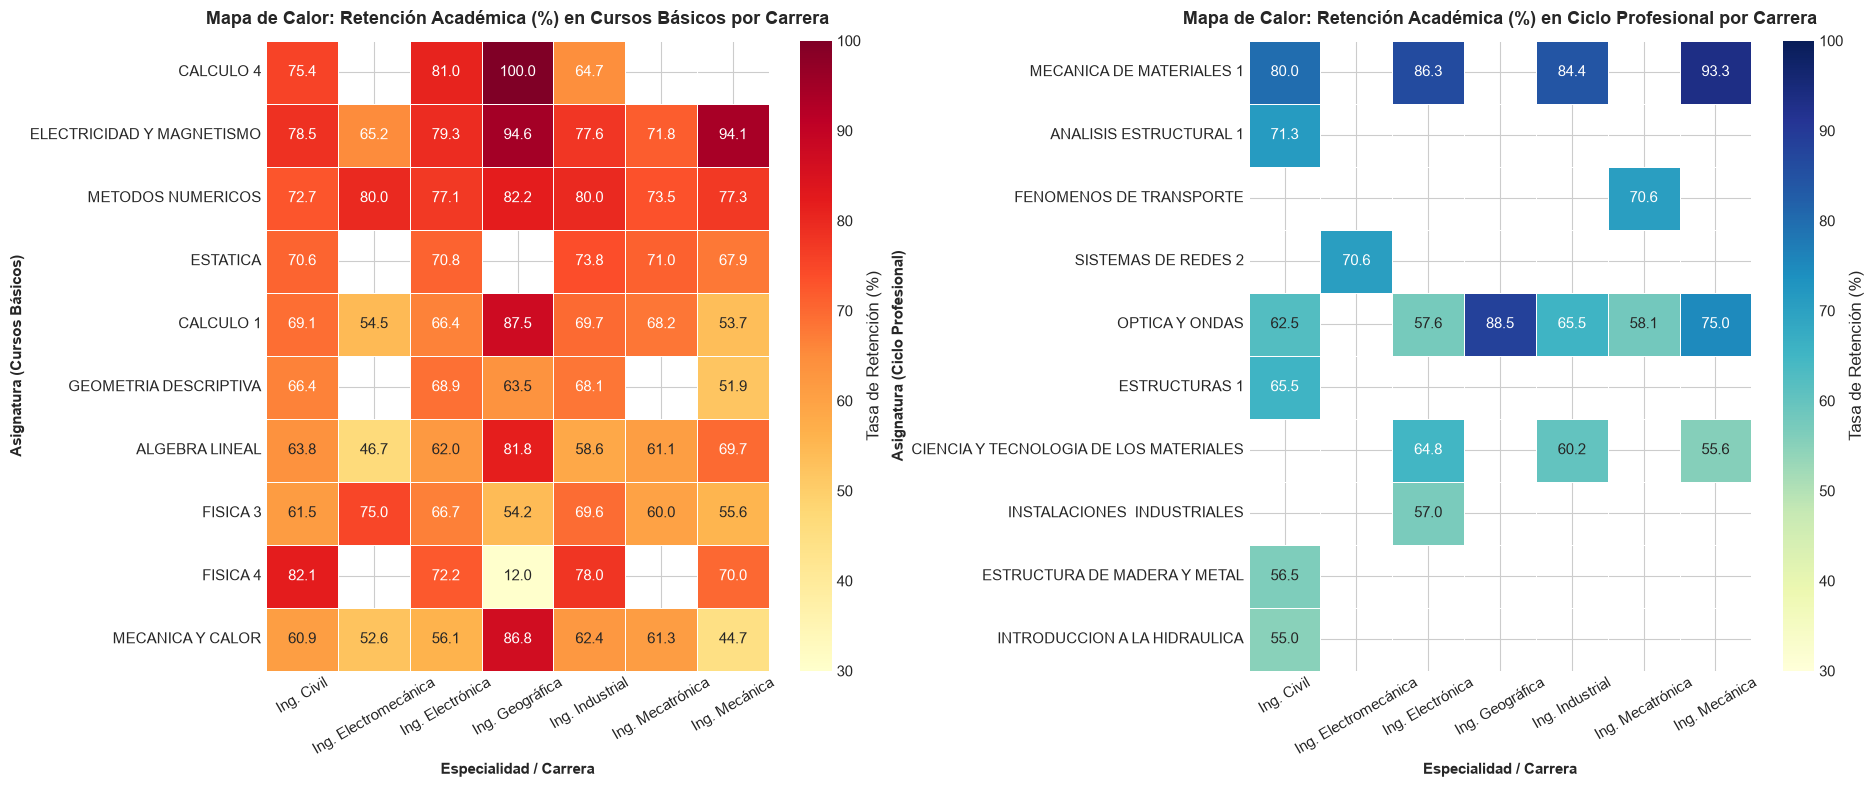

In [5]:
def plot_retention_by_cycle_and_career(df: pd.DataFrame, min_students: int = 15):
    '''
    Representación Matricial de Calor (Heatmap) para la Retención Académica por Ciclo y Carrera:
    Evita la saturación visual agrupando asignaturas en filas y especialidades en columnas,
    distinguiendo entre Cursos Básicos y Ciclo Profesional con valores numéricos legibles sin solapamiento.
    '''
    career_map = {
        'CIV': 'Ing. Civil', 'ELE': 'Ing. Electrónica', 'MCT': 'Ing. Mecatrónica',
        'IND': 'Ing. Industrial', 'CGF': 'Ing. Geográfica', 'MEC': 'Ing. Mecánica', 'ECA': 'Ing. Electromecánica'
    }
    
    df_work = df.copy()
    df_work['Carrera_Nombre'] = df_work['Carrera_Corta'].map(career_map)
    df_filtered = df_work.dropna(subset=['Carrera_Nombre']).copy()
    
    # Agrupación y cálculo de tasa de retención con filtro de representatividad (N >= min_students)
    agg_df = df_filtered.groupby(['Tipo_Ciclo', 'Asignatura', 'Carrera_Nombre']).agg(
        Total=('Aprobado', 'count'),
        Retencion=('Aprobado', lambda s: (s == 'N').mean() * 100)
    ).reset_index()
    
    agg_valid = agg_df[agg_df['Total'] >= min_students].copy()
    
    # 1. Cursos Básicos: Top 10 asignaturas por promedio de retención
    basic_valid = agg_valid[agg_valid['Tipo_Ciclo'] == 'Cursos Básicos']
    top_basic_subjects = basic_valid.groupby('Asignatura')['Retencion'].mean().sort_values(ascending=False).head(10).index
    pivot_basic = basic_valid[basic_valid['Asignatura'].isin(top_basic_subjects)].pivot(
        index='Asignatura', columns='Carrera_Nombre', values='Retencion'
    ).reindex(top_basic_subjects)
    
    # 2. Ciclo Profesional: Top 10 asignaturas por promedio de retención
    prof_valid = agg_valid[agg_valid['Tipo_Ciclo'] == 'Ciclo Profesional']
    top_prof_subjects = prof_valid.groupby('Asignatura')['Retencion'].mean().sort_values(ascending=False).head(10).index
    pivot_prof = prof_valid[prof_valid['Asignatura'].isin(top_prof_subjects)].pivot(
        index='Asignatura', columns='Carrera_Nombre', values='Retencion'
    ).reindex(top_prof_subjects)
    
    # Renderizado de Mapas de Calor Paralelos
    fig, axes = plt.subplots(1, 2, figsize=(19, 8))
    
    # Heatmap Cursos Básicos
    sns.heatmap(
        pivot_basic, annot=True, fmt='.1f', cmap='YlOrRd', vmin=30, vmax=100,
        linewidths=0.7, linecolor='white', cbar_kws={'label': 'Tasa de Retención (%)'}, ax=axes[0]
    )
    axes[0].set_title('Mapa de Calor: Retención Académica (%) en Cursos Básicos por Carrera', fontsize=13, weight='bold', pad=12)
    axes[0].set_xlabel('Especialidad / Carrera', fontsize=11, weight='bold')
    axes[0].set_ylabel('Asignatura (Cursos Básicos)', fontsize=11, weight='bold')
    axes[0].tick_params(axis='x', rotation=30)
    
    # Heatmap Ciclo Profesional
    sns.heatmap(
        pivot_prof, annot=True, fmt='.1f', cmap='YlGnBu', vmin=30, vmax=100,
        linewidths=0.7, linecolor='white', cbar_kws={'label': 'Tasa de Retención (%)'}, ax=axes[1]
    )
    axes[1].set_title('Mapa de Calor: Retención Académica (%) en Ciclo Profesional por Carrera', fontsize=13, weight='bold', pad=12)
    axes[1].set_xlabel('Especialidad / Carrera', fontsize=11, weight='bold')
    axes[1].set_ylabel('Asignatura (Ciclo Profesional)', fontsize=11, weight='bold')
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.show()

plot_retention_by_cycle_and_career(df_raw)

### 2.C. Histograma del Score de Rendimiento por Carrera por Semestre

Evaluamos la distribución del **Score de Rendimiento Académico** (promedio de parciales) desglosado por cada **Semestre** lectivo y comparado entre las distintas carreras de Ingeniería.


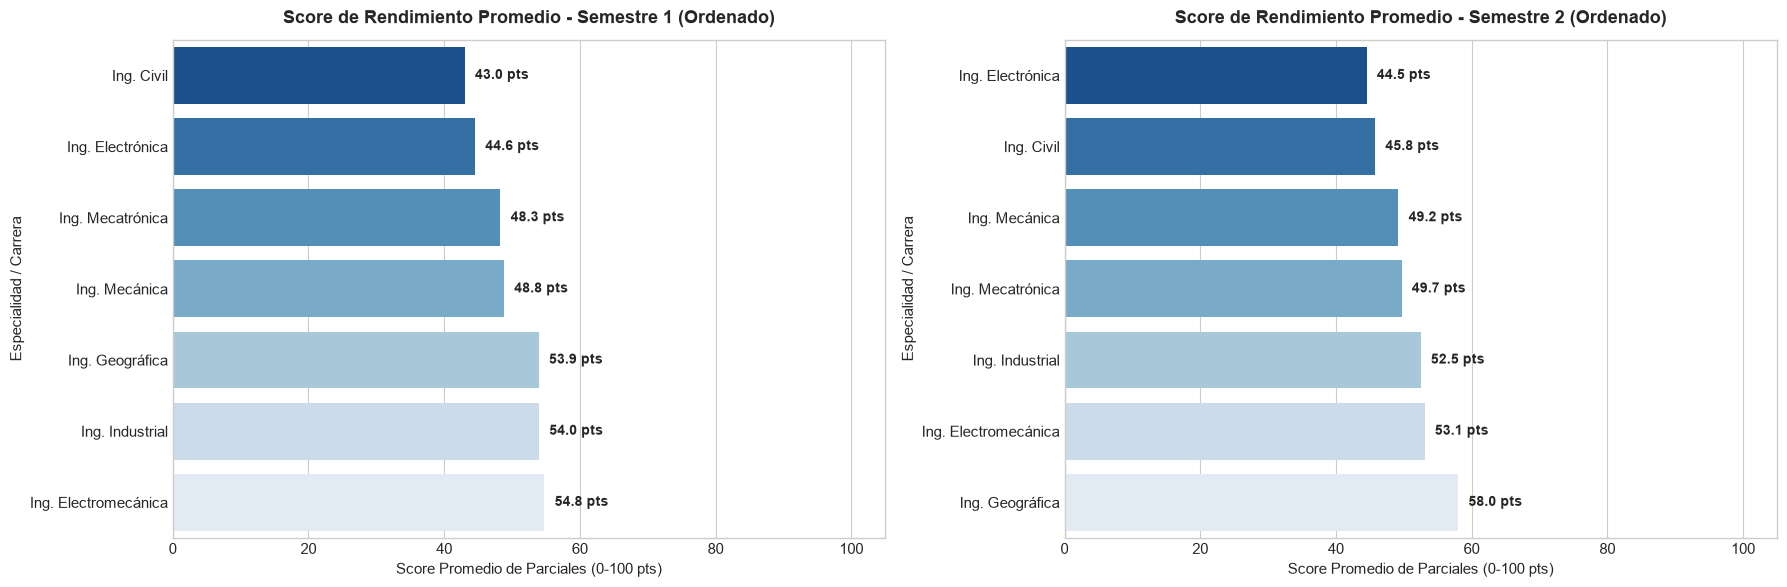

In [6]:
def plot_performance_score_by_semester_and_career(df: pd.DataFrame):
    '''
    Visualización Limpia y Ordenada por Semestre:
    Muestra el Score de Rendimiento Promedio por Carrera desglosado horizontalmente por Semestre.
    '''
    career_map = {
        'CIV': 'Ing. Civil', 'ELE': 'Ing. Electrónica', 'MCT': 'Ing. Mecatrónica',
        'IND': 'Ing. Industrial', 'CGF': 'Ing. Geográfica', 'MEC': 'Ing. Mecánica', 'ECA': 'Ing. Electromecánica'
    }
    
    df_work = df.copy()
    df_work['Carrera_Nombre'] = df_work['Carrera_Corta'].map(career_map)
    df_sub = df_work.dropna(subset=['Carrera_Nombre']).copy()
    
    semestres = sorted(df_sub['Semestre'].unique())
    fig, axes = plt.subplots(1, len(semestres), figsize=(18, 6))
    if len(semestres) == 1:
        axes = [axes]
        
    for i, sem in enumerate(semestres):
        df_sem = df_sub[df_sub['Semestre'] == sem]
        
        # Rendimiento promedio ordenado de mayor a menor
        means = df_sem.groupby('Carrera_Nombre')['Score_Rendimiento'].mean().sort_values(ascending=True).reset_index()
        
        sns.barplot(
            data=means, x='Score_Rendimiento', y='Carrera_Nombre', hue='Carrera_Nombre',
            palette='Blues_r', ax=axes[i], legend=False
        )
        
        axes[i].set_title(f'Score de Rendimiento Promedio - Semestre {sem} (Ordenado)', fontsize=13, weight='bold', pad=12)
        axes[i].set_xlabel('Score Promedio de Parciales (0-100 pts)', fontsize=11)
        axes[i].set_ylabel('Especialidad / Carrera', fontsize=11)
        axes[i].set_xlim(0, 105)
        
        # Anotación exacta centrada
        for p in axes[i].patches:
            val = p.get_width()
            if not np.isnan(val) and val > 0:
                axes[i].annotate(
                    f'{val:.1f} pts',
                    (val + 1.5, p.get_y() + p.get_height() / 2.),
                    va='center', fontsize=10, weight='bold'
                )
                
    plt.tight_layout()
    plt.show()

plot_performance_score_by_semester_and_career(df_raw)

C:\Users\Carlos Benitez\AppData\Local\Temp\ipykernel_18576\3843691337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condicion_riesgo', y='Primer_Parcial', data=df, ax=axes[0], palette='Set2')


C:\Users\Carlos Benitez\AppData\Local\Temp\ipykernel_18576\3843691337.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='condicion_riesgo', y='Segundo_Parcial', data=df, ax=axes[1], palette='Set2', split=True)


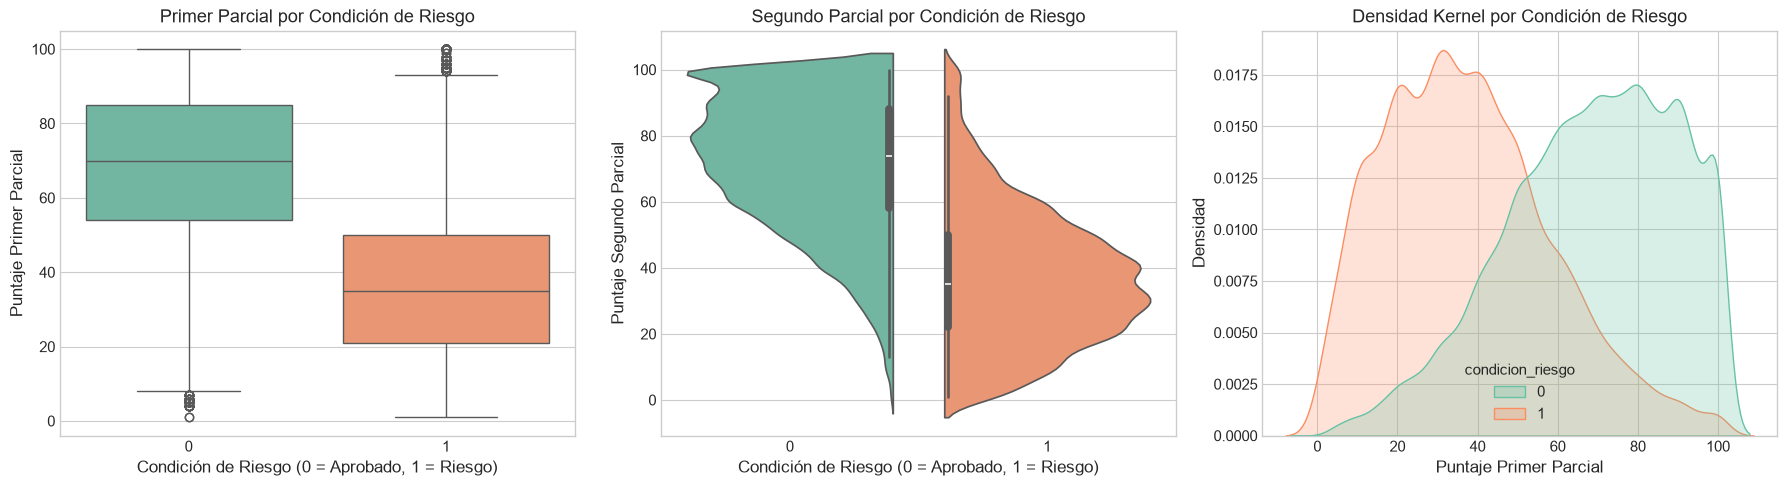

In [7]:
def plot_eda_risk_condition_comparisons(df: pd.DataFrame):
    """
    Visualización Intermedia y Avanzada: Boxplot, Violin plot y Densidad KDE por Condición de Riesgo.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Boxplot del Primer Parcial según Condición de Riesgo
    sns.boxplot(x='condicion_riesgo', y='Primer_Parcial', data=df, ax=axes[0], palette='Set2')
    axes[0].set_title('Primer Parcial por Condición de Riesgo')
    axes[0].set_xlabel('Condición de Riesgo (0 = Aprobado, 1 = Riesgo)')
    axes[0].set_ylabel('Puntaje Primer Parcial')
    
    # 2. Violin plot del Segundo Parcial según Condición de Riesgo
    sns.violinplot(x='condicion_riesgo', y='Segundo_Parcial', data=df, ax=axes[1], palette='Set2', split=True)
    axes[1].set_title('Segundo Parcial por Condición de Riesgo')
    axes[1].set_xlabel('Condición de Riesgo (0 = Aprobado, 1 = Riesgo)')
    axes[1].set_ylabel('Puntaje Segundo Parcial')
    
    # 3. Densidad KDE del Primer Parcial por Condición de Riesgo
    sns.kdeplot(data=df, x='Primer_Parcial', hue='condicion_riesgo', fill=True, common_norm=False, palette='Set2', ax=axes[2])
    axes[2].set_title('Densidad Kernel por Condición de Riesgo')
    axes[2].set_xlabel('Puntaje Primer Parcial')
    axes[2].set_ylabel('Densidad')
    
    plt.tight_layout()
    plt.show()

plot_eda_risk_condition_comparisons(df_raw)


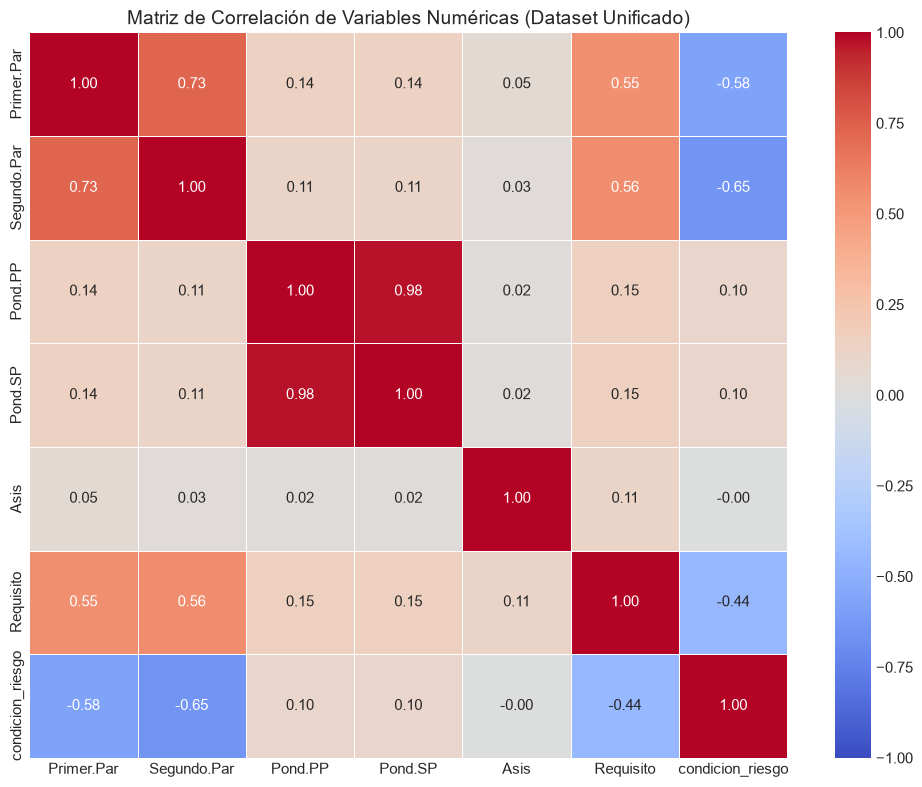

In [8]:
def plot_correlation_matrix_dashboard(df: pd.DataFrame):
    """
    Calcula y gráfica la Matriz de Correlación para variables numéricas.
    """
    numeric_df = df[['Primer.Par', 'Segundo.Par', 'Pond.PP', 'Pond.SP', 'Asis', 'Requisito', 'condicion_riesgo']].select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
    plt.title('Matriz de Correlación de Variables Numéricas (Dataset Unificado)', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_correlation_matrix_dashboard(df_raw)


## 3. Limpieza, Imputación Directa e Imputación Avanzada

Siguiendo el protocolo estricto presentado en `Preprocesamiento.ipynb` y la Clase 3, se realiza la partición estricta en conjunto de entrenamiento ($D_{train}$, 80%) y evaluación ($D_{test}$, 20%) **antes de cualquier cálculo de imputación o escalado**, para evitar el sesgo por fuga de información (*Data Leakage*).

### Formulaciones Matemáticas de Imputación
1. **Imputación por Media**: $\hat{x}_{j} = \frac{1}{|I_{obs}|} \sum_{i \in I_{obs}} x_{ij}$
2. **Imputación KNN**:
   $$\hat{x}_{ij} = \frac{\sum_{k \in N_K(i)} w_k x_{kj}}{\sum_{k \in N_K(i)} w_k}, \quad w_k = \frac{1}{d(x_i, x_k)}$$


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer

target_col = 'condicion_riesgo'

num_features = ['Primer_Parcial', 'Segundo_Parcial', 'Pond.PP', 'Pond.SP', 'Asis']
cat_features = ['Cod.Car.Sec', 'Convocatoria', 'Semestre']

feature_cols = num_features + cat_features

df_clean_base = df_raw.dropna(subset=[target_col]).copy()
X = df_clean_base[feature_cols]
y = df_clean_base[target_col]

# Partición rigurosa Train (80%) vs Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"-> Partición efectuada:")
print(f"   - Conjunto de Entrenamiento (Train): {X_train.shape[0]} muestras")
print(f"   - Conjunto de Evaluación (Test):     {X_test.shape[0]} muestras")


-> Partición efectuada:
   - Conjunto de Entrenamiento (Train): 51436 muestras
   - Conjunto de Evaluación (Test):     12859 muestras


In [10]:
# 1. Imputación Simple (Media) calculada SOLO en Train
imputer_mean = SimpleImputer(strategy='mean')
X_train_num_imputed_mean = pd.DataFrame(
    imputer_mean.fit_transform(X_train[num_features]),
    columns=num_features,
    index=X_train.index
)
X_test_num_imputed_mean = pd.DataFrame(
    imputer_mean.transform(X_test[num_features]),
    columns=num_features,
    index=X_test.index
)

# 2. Imputación KNN (K=5) calculada SOLO en Train
imputer_knn = KNNImputer(n_neighbors=5)
X_train_num_imputed_knn = pd.DataFrame(
    imputer_knn.fit_transform(X_train[num_features]),
    columns=num_features,
    index=X_train.index
)
X_test_num_imputed_knn = pd.DataFrame(
    imputer_knn.transform(X_test[num_features]),
    columns=num_features,
    index=X_test.index
)

print("-> Imputaciones (Mean y KNN) ajustadas estrictamente en Train y transformadas en Test.")


-> Imputaciones (Mean y KNN) ajustadas estrictamente en Train y transformadas en Test.


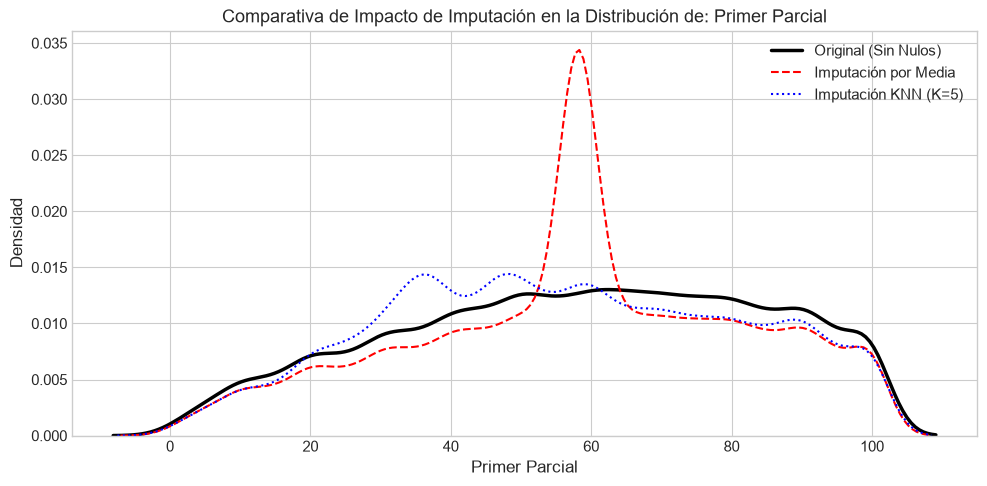

In [11]:
def plot_imputation_comparison(orig_series, mean_series, knn_series, feature_name):
    """
    Compara gráficamente las distribuciones antes y después de imputar.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.kdeplot(orig_series.dropna(), ax=ax, label='Original (Sin Nulos)', color='black', linewidth=2.5)
    sns.kdeplot(mean_series, ax=ax, label='Imputación por Media', color='red', linestyle='--')
    sns.kdeplot(knn_series, ax=ax, label='Imputación KNN (K=5)', color='blue', linestyle=':')
    
    ax.set_title(f'Comparativa de Impacto de Imputación en la Distribución de: {feature_name}')
    ax.set_xlabel(feature_name)
    ax.set_ylabel('Densidad')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_imputation_comparison(
    X_train['Primer_Parcial'],
    X_train_num_imputed_mean['Primer_Parcial'],
    X_train_num_imputed_knn['Primer_Parcial'],
    'Primer Parcial'
)


## 4. Detección y Verificación de Outliers en Datos Tabulares

Analizaremos la presencia de anomalías o valores atípicos (*outliers*) aplicando métodos univariados (Z-Score e IQR) y multivariados (`IsolationForest`).

### Formulaciones Matemáticas
1. **Filtro Z-Score**: $Z_i = \frac{x_i - \mu}{\sigma}, \quad \text{Outlier si } |Z_i| > 3.0$
2. **Criterio IQR**: $x \notin [Q_1 - 1.5 \cdot IQR, \; Q_3 + 1.5 \cdot IQR]$
3. **Isolation Forest**: Basado en árboles aleatorios donde el número de particiones requeridas para aislar la observación $x$ determina el *score* de anomalía $s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$.


In [12]:
from sklearn.ensemble import IsolationForest

def fit_outlier_detectors(df_tr_num: pd.DataFrame):
    """
    Ajusta detectores Z-Score, IQR e Isolation Forest en Train.
    """
    stats = {}
    for col in df_tr_num.columns:
        mean_val = df_tr_num[col].mean()
        std_val = df_tr_num[col].std()
        q1 = df_tr_num[col].quantile(0.25)
        q3 = df_tr_num[col].quantile(0.75)
        iqr = q3 - q1
        stats[col] = {
            'mean': mean_val, 'std': std_val,
            'iqr_lower': q1 - 1.5 * iqr, 'iqr_upper': q3 + 1.5 * iqr
        }
        
    iso = IsolationForest(contamination=0.05, random_state=42)
    iso.fit(df_tr_num)
    
    return stats, iso

stats_train, iso_forest = fit_outlier_detectors(X_train_num_imputed_mean)

# Predicción de anómalo (-1) o normal (1) en Train con Isolation Forest
outliers_iso_train = iso_forest.predict(X_train_num_imputed_mean)
n_outliers = (outliers_iso_train == -1).sum()
print(f"-> Isolation Forest detectó {n_outliers} outliers ({n_outliers/len(X_train)*100:.2f}%) en el conjunto de Train.")


-> Isolation Forest detectó 2559 outliers (4.98%) en el conjunto de Train.


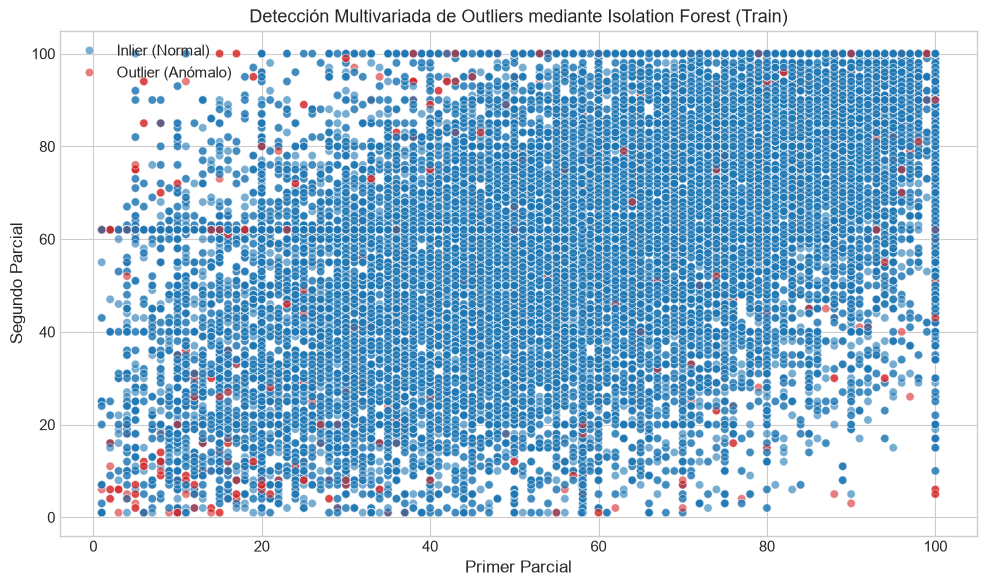

In [13]:
def plot_outliers_visualization(df_num: pd.DataFrame, outliers_pred: np.ndarray):
    """
    Visualización de outliers identificados por Isolation Forest.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.scatterplot(
        x=df_num['Primer_Parcial'],
        y=df_num['Segundo_Parcial'],
        hue=(outliers_pred == -1),
        palette={False: '#1f77b4', True: '#d62728'},
        alpha=0.6,
        ax=ax
    )
    
    ax.set_title('Detección Multivariada de Outliers mediante Isolation Forest (Train)')
    ax.set_xlabel('Primer Parcial')
    ax.set_ylabel('Segundo Parcial')
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ['Inlier (Normal)', 'Outlier (Anómalo)'])
    plt.tight_layout()
    plt.show()

plot_outliers_visualization(X_train_num_imputed_mean, outliers_iso_train)


## 5. Escalado de Características y Codificación Categórica (*Encoding*)

En esta sección se abordan la transformación y el escalado de características numéricas y categóricas para acondicionar las variables para algoritmos sensibles a la magnitud.

### Formulaciones Matemáticas
1. **StandardScaler (Z-Score Standardization)**: $x' = \frac{x - \mu}{\sigma}$
2. **MinMaxScaler**: $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$
3. **RobustScaler**: $x' = \frac{x - Q_2}{Q_3 - Q_1}$
4. **OneHotEncoder**: Convierte cada nivel categórico $c \in C$ en un vector binario $e \in \{0, 1\}^{|C|}$.


In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder

# A. Escalado de Variables Numéricas
scaler_std = StandardScaler()
X_train_num_scaled = scaler_std.fit_transform(X_train_num_imputed_mean)
X_test_num_scaled = scaler_std.transform(X_test_num_imputed_mean)

# B. Codificación Categórica mediante OneHotEncoder
encoder_oh = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat_encoded = encoder_oh.fit_transform(X_train[cat_features])
X_test_cat_encoded = encoder_oh.transform(X_test[cat_features])

# Concatenación de características procesadas
X_train_processed = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_test_processed = np.hstack([X_test_num_scaled, X_test_cat_encoded])

print(f"-> Matriz procesada Train: {X_train_processed.shape[0]} muestras x {X_train_processed.shape[1]} características.")
print(f"-> Matriz procesada Test:  {X_test_processed.shape[0]} muestras x {X_test_processed.shape[1]} características.")


-> Matriz procesada Train: 51436 muestras x 36 características.
-> Matriz procesada Test:  12859 muestras x 36 características.


## 6. Reducción de Dimensionalidad con PCA

El Análisis de Componentes Principales (PCA) proyecta los datos escalados a un subespacio ortogonal que maximiza la varianza explicada.

### Formulación Matemática de PCA
Dada la matriz centrada $X$, la matriz de covarianza es $\Sigma = \frac{1}{N-1} X^T X$. Mediante la descomposición en autovalores:
$$\Sigma v_k = \lambda_k v_k$$
La varianza explicada acumulada por $K$ componentes principales se define como:
$$\text{Varianza Acumulada}(K) = \frac{\sum_{k=1}^K \lambda_k}{\sum_{j=1}^D \lambda_j}$$


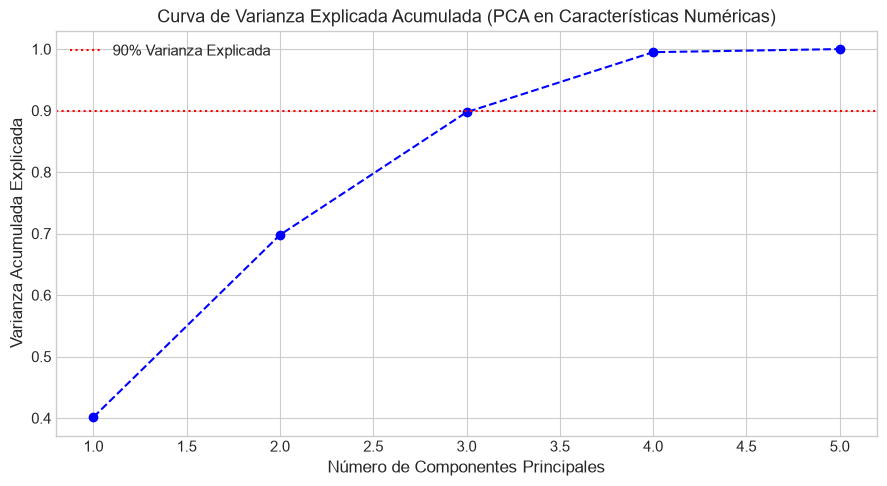

In [15]:
from sklearn.decomposition import PCA

# Ajuste de PCA en la matriz numérica escalada de Train
pca_full = PCA(random_state=42).fit(X_train_num_scaled)
var_explained_cum = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(var_explained_cum) + 1), var_explained_cum, marker='o', linestyle='--', color='b')
ax.axhline(0.90, color='r', linestyle=':', label='90% Varianza Explicada')
ax.set_title('Curva de Varianza Explicada Acumulada (PCA en Características Numéricas)')
ax.set_xlabel('Número de Componentes Principales')
ax.set_ylabel('Varianza Acumulada Explicada')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Entrenamiento y Evaluación de un Modelo Simple (Baseline)

Integrando las secciones presentadas en `modeloSimple.ipynb`, entrenamos clasificadores simples (Regresión Logística y Bosques Aleatorios) para predecir la variable objetivo `condicion_riesgo`.

### Métricas de Evaluación
- **Accuracy**: $\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$
- **Precision**: $\text{Precision} = \frac{TP}{TP + FP}$
- **Recall**: $\text{Recall} = \frac{TP}{TP + FN}$
- **F1-Score**: $F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# 1. Modelo de Regresión Logística
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_processed, y_train)
y_pred_lr = model_lr.predict(X_test_processed)
y_prob_lr = model_lr.predict_proba(X_test_processed)[:, 1]

# 2. Modelo de Random Forest (Baseline)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_processed, y_train)
y_pred_rf = model_rf.predict(X_test_processed)
y_prob_rf = model_rf.predict_proba(X_test_processed)[:, 1]

print("=== REPORTE DE CLASIFICACIÓN (REGRESIÓN LOGÍSTICA - TEST) ===")
print(classification_report(y_test, y_pred_lr))


=== REPORTE DE CLASIFICACIÓN (REGRESIÓN LOGÍSTICA - TEST) ===
              precision    recall  f1-score   support

           0       0.75      0.83      0.79      7801
           1       0.68      0.57      0.62      5058

    accuracy                           0.73     12859
   macro avg       0.72      0.70      0.70     12859
weighted avg       0.72      0.73      0.72     12859



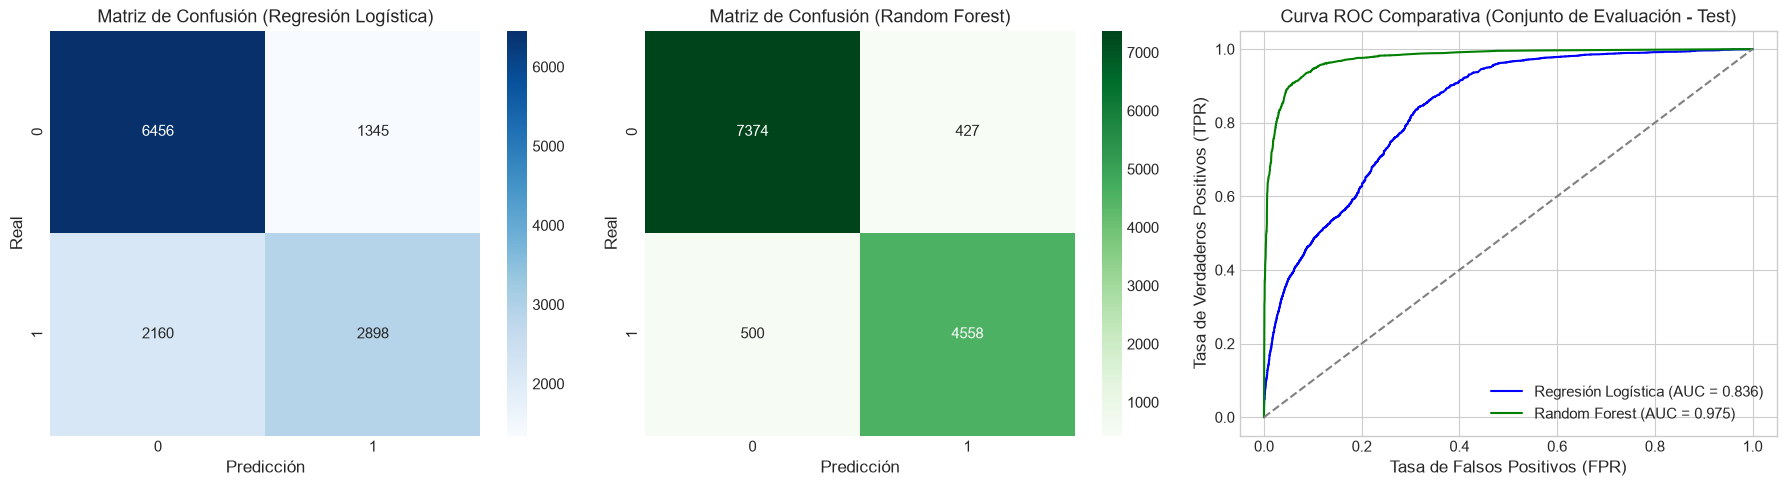

In [17]:
def plot_model_evaluation_dashboards(y_true, y_pred_lr, y_prob_lr, y_pred_rf, y_prob_rf):
    """
    Genera matrices de confusión y curvas ROC para los modelos entrenados.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Matriz de Confusión Regresión Logística
    cm_lr = confusion_matrix(y_true, y_pred_lr)
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Matriz de Confusión (Regresión Logística)')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    
    # 2. Matriz de Confusión Random Forest
    cm_rf = confusion_matrix(y_true, y_pred_rf)
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title('Matriz de Confusión (Random Forest)')
    axes[1].set_xlabel('Predicción')
    axes[1].set_ylabel('Real')
    
    # 3. Curva ROC Comparativa
    fpr_lr, tpr_lr, _ = roc_curve(y_true, y_prob_lr)
    auc_lr = auc(fpr_lr, tpr_lr)
    
    fpr_rf, tpr_rf, _ = roc_curve(y_true, y_prob_rf)
    auc_rf = auc(fpr_rf, tpr_rf)
    
    axes[2].plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {auc_lr:.3f})', color='blue')
    axes[2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='green')
    axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[2].set_title('Curva ROC Comparativa (Conjunto de Evaluación - Test)')
    axes[2].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axes[2].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

plot_model_evaluation_dashboards(y_test, y_pred_lr, y_prob_lr, y_pred_rf, y_prob_rf)


## 8. Encapsulamiento en Pipeline de Scikit-Learn y Resumen Pedagógico

El paso final para la puesta en producción es encapsular todos los pasos de preprocesamiento (Imputación + Escalado + Codificación Categórica) y el estimador final en un único objeto `Pipeline` de Scikit-Learn mediante `ColumnTransformer`.


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 1. Pipeline numérico: Imputación + Escalado
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# 2. Pipeline categórico: Imputación + OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

# 4. Pipeline Final de Producción
production_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenamiento completo del Pipeline en X_train
production_pipeline.fit(X_train, y_train)

# Inferencia en X_test
y_pipeline_pred = production_pipeline.predict(X_test)
pipeline_accuracy = accuracy_score(y_test, y_pipeline_pred)

print("-> Pipeline de producción entrenado exitosamente.")
print(f"   Exactitud (Accuracy) obtenida en el conjunto de prueba (Test): {pipeline_accuracy * 100:.2f}%")


-> Pipeline de producción entrenado exitosamente.
   Exactitud (Accuracy) obtenida en el conjunto de prueba (Test): 72.74%


## Resumen y Conclusiones Pedagógicas

En este cuaderno de práctica integrada para la **Clase 4**:

1. **Unificación y Auditoría Profunda**: Se consolidó la base de datos unificada de **64,295 registros y 29 variables** (`reglamento_nuevo_unificado.csv`), efectuando un diagnóstico exhaustivo de valores faltantes (`NaN`), ceros estructurales y momentos estadísticos (Media, Mediana, Std, Asimetría y Curtosis).
2. **Análisis Exploratorio Multidimensional**: Se incluyeron histogramas comparativos del **Top 10 de materias con mayor retención en Cursos Básicos vs. Ciclo Profesional separadas por carrera**, e **histogramas por Semestre del score de rendimiento por carrera**, previos a la matriz de correlación anotada.
3. **Protocolo Estricto de Preprocesamiento**: Se garantizó la ausencia de *Data Leakage* realizando la partición Train/Test previa a la imputación (`SimpleImputer`, `KNNImputer`), escalado (`StandardScaler`) y codificación categórica (`OneHotEncoder`).
4. **Tratamiento de Outliers y PCA**: Se exploró la detección multivariada con `IsolationForest` y la proyección ortogonal por `PCA`.
5. **Modelado y Evaluación**: Se construyeron modelos baseline (`modeloSimple.ipynb`) de Regresión Logística y Random Forest, evaluando su desempeño mediante métricas de clasificación, matrices de confusión y curvas ROC-AUC.
6. **Despliegue e Inferencia**: Se encapsuló el flujo completo mediante `Pipeline` y `ColumnTransformer`, garantizando la interpretabilidad y la preparación del modelo para entornos de producción.
